06:20:01 - cmdstanpy - INFO - Chain [1] start processing
06:20:22 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\BUI QUANG HUNG\AppData\Local\Programs\Python\Python313\Lib\site-packages\prophet\forecaster.py:1875: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(


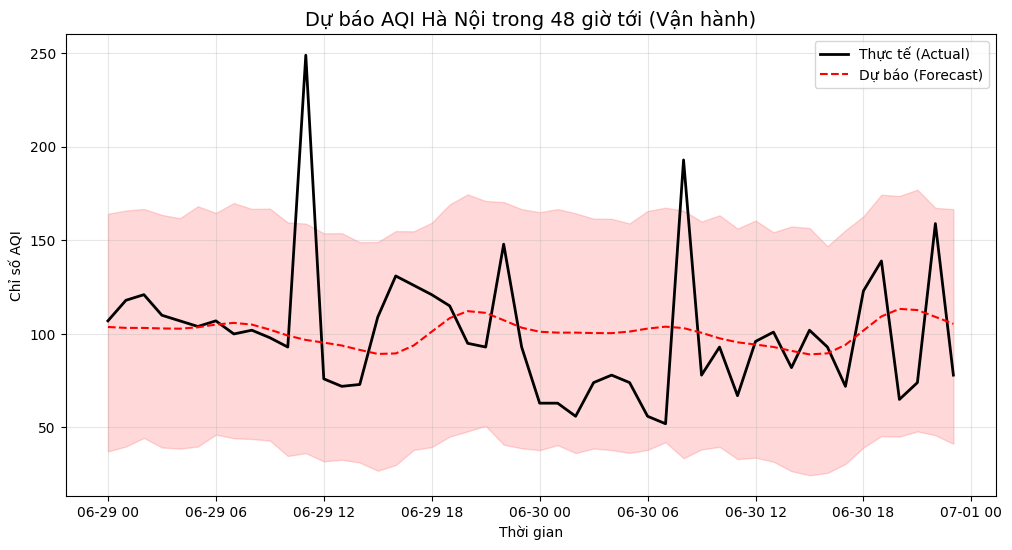

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet

# 1. Đọc dữ liệu
df = pd.read_csv('../clean/hanoi_aqi_cleaned.csv')
df['ds'] = pd.to_datetime(df['local_time'])
df['y'] = df['aqi']

# 2. Chia dữ liệu: Lấy 48 giờ cuối để dự báo vận hành
test_size = 48
train, test = df.iloc[:-test_size], df.iloc[-test_size:]

# 3. Huấn luyện mô hình
model = Prophet(daily_seasonality=True, yearly_seasonality=True).fit(train)

# 4. Dự báo 48 giờ
future = model.make_future_dataframe(periods=test_size, freq='H')
forecast = model.predict(future)

# 5. Vẽ biểu đồ dự báo 48h (Dành cho báo cáo vận hành)
plt.figure(figsize=(12, 6))
plt.plot(test['ds'], test['y'], label='Thực tế (Actual)', color='black', linewidth=2)
plt.plot(forecast['ds'].tail(test_size), forecast['yhat'].tail(test_size), 
         label='Dự báo (Forecast)', color='red', linestyle='--')
plt.fill_between(forecast['ds'].tail(test_size), 
                 forecast['yhat_lower'].tail(test_size), 
                 forecast['yhat_upper'].tail(test_size), color='red', alpha=0.15)

plt.title('Dự báo AQI Hà Nội trong 48 giờ tới (Vận hành)', fontsize=14)
plt.xlabel('Thời gian'); plt.ylabel('Chỉ số AQI')
plt.legend(); plt.grid(alpha=0.3); plt.show()